In [1]:
import nifty.re as jft
from jax import random
from jax import numpy as jnp
import numpy as np
import jax

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

jax.config.update("jax_enable_x64", True)

shape = 200
distances = 5
seed = 50
key = random.PRNGKey(seed)

In [2]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [3]:
cf_kwargs = {
    "offset_mean": 21.0,
    "offset_std": (1.0, 1e-3),
    "fluctuations": (2.0, 1.0),
    "loglogavgslope": (-2.0, 0.3),
    "flexibility": (2.0, 1.0),
    "asperity": (1.0, 0.5),
    "prefix": "",
}

In [4]:
model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

In [5]:
key, *subkeys = random.split(key, 5)
xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

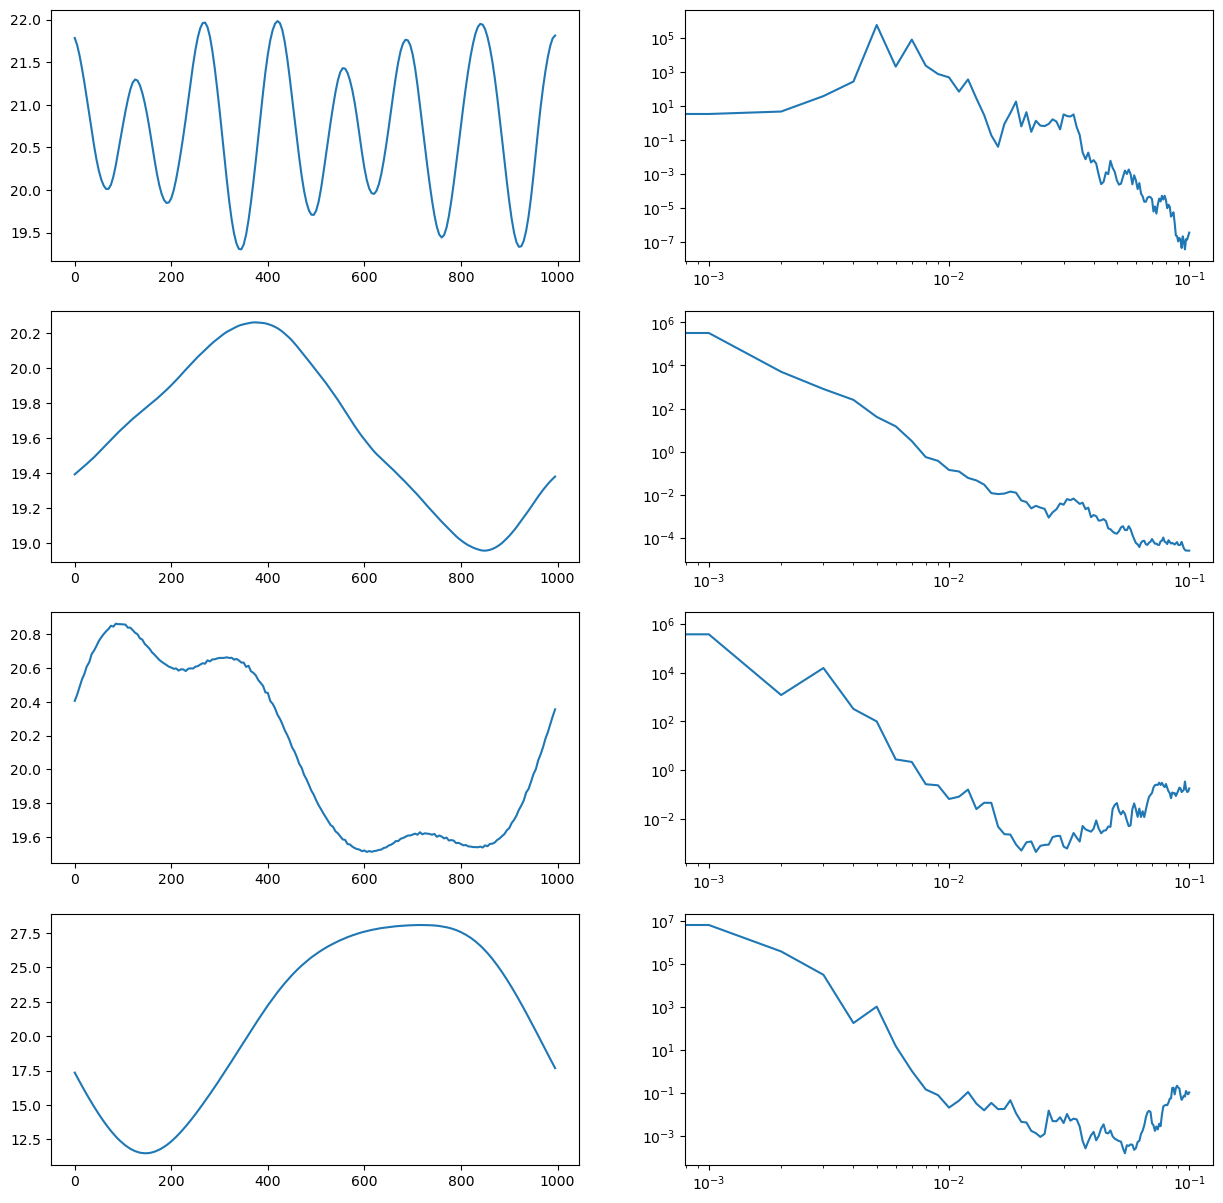

In [6]:
x_vec = model.target_grids[0].distances[0] * np.arange(
    shape
)  # sampling points of Gaussian process
k_vec = model.target_grids[
    0
].harmonic_grid.mode_lengths  # fourier modes of amplitude spectrum

fig, axes = plt.subplots(len(xi_samples), 2, figsize=(15, 15))
for i, xi in enumerate(xi_samples):
    axes[i, 0].plot(x_vec, model(xi))
    axes[i, 1].loglog(k_vec, ps(xi))
plt.show()

In [7]:
t = np.load("data/time_200.npy")
true = np.load("data/true_trace_200.npy")

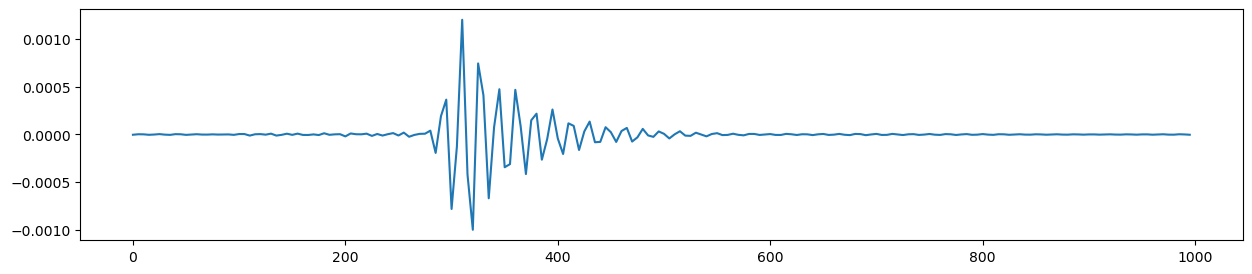

In [8]:
plt.figure(figsize=(15, 3))
plt.plot(t, true)
plt.show()

In [9]:
shape = 200
distances = 5e-9

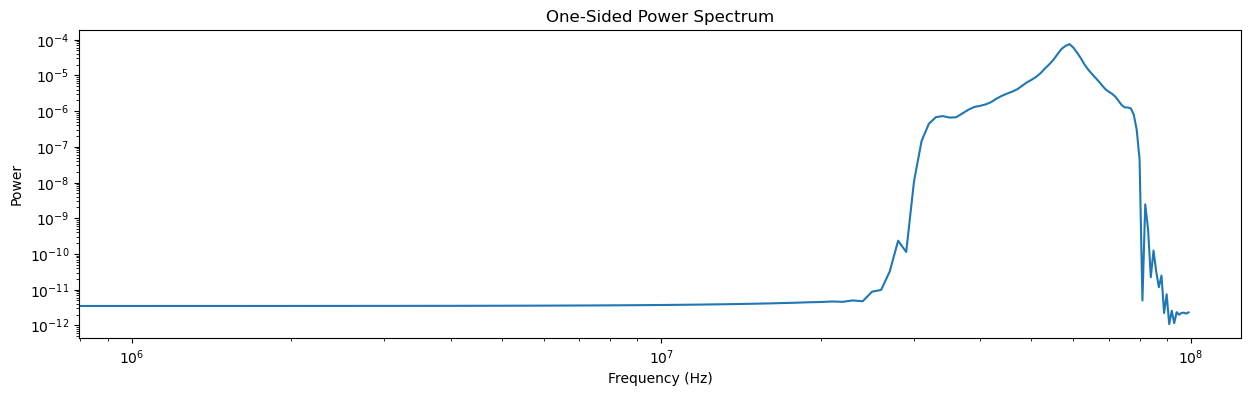

In [10]:
# 1. Generate a mock time-series signal
time_step = 5e-9
t = np.arange(0, 200)*time_step

# 2. Compute the Fast Fourier Transform (FFT)
fft_result = np.fft.fft(true)

# 3. Calculate the power spectrum (squared magnitude)
power_spectrum = np.abs(fft_result) ** 2

# 4. Generate the corresponding frequencies
frequencies = np.fft.fftfreq(true.size, d=time_step)

# 5. Extract the positive (one-sided) frequencies for real-valued inputs
positive_frequencies_mask = frequencies >= 0
freqs_side = frequencies[positive_frequencies_mask]
power_side = power_spectrum[positive_frequencies_mask]

# 6. Plot the power spectrum
plt.figure(figsize=(15, 4))
plt.plot(freqs_side, power_side)
plt.title("One-Sided Power Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.loglog()
plt.show()

# Actual Modeling Part

In [11]:
def gaussian_window(x, x0, sigma):
    return np.exp(-(x-x0)**2/(2*sigma**2))

In [12]:
x_vec[np.argmax(true)]

np.int64(310)

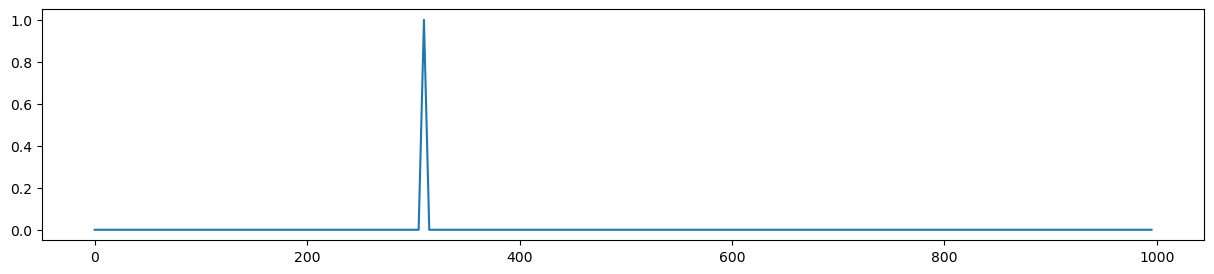

In [13]:
y = gaussian_window(x_vec, x_vec[np.argmax(true)], 0.03e-6)
plt.figure(figsize=(15,3))
plt.plot(x_vec, y)
plt.show()

In [14]:
class SignalModel(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, x_grid):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma**2))

    def __call__(self, x):
        cfm_nonperiodic = self.cf_model(x)[100:300]
        return self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), 0.03e-6)



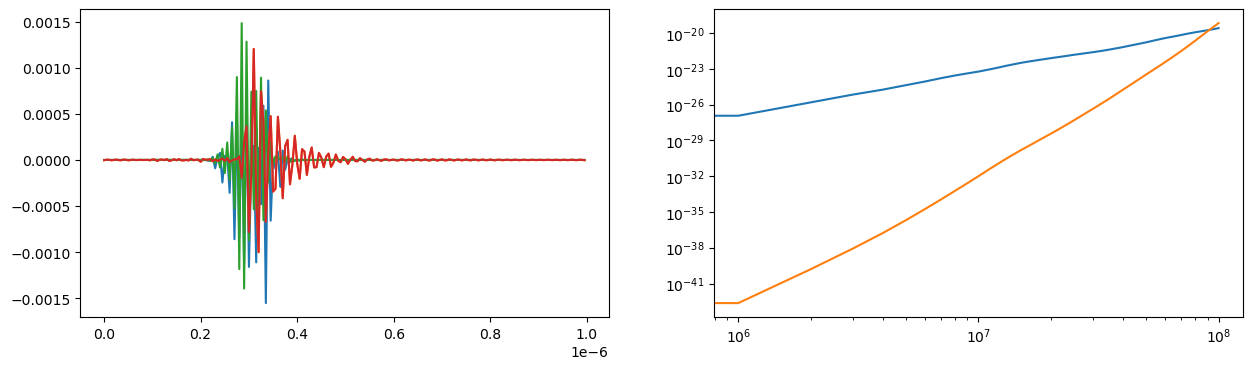

In [15]:
cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (1e-3, 1e-4),
    "loglogavgslope": (5., 1.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
}

window_mean_pos_prior = jft.NormalPrior(mean=3.1e-7, std=1e-8, name='mean_pos_window', shape=(1,))

# cf_kwargs = {
#     "offset_mean": 0,
#     "offset_std": (1e-3, 5e-4),
#     "fluctuations": (5e-4, 2e-4),
#     "loglogavgslope":(-3.0, 1.0),
#     "flexibility": (0.5, 0.3),
#     "asperity": (0.1, 0.05),
#     "prefix": "",
# }

shape = 200
distances = 5e-9

# model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

# key, *subkeys = random.split(key, 2)
# xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

# x_vec = model.target_grids[0].distances[0] * np.arange(
#     shape
# )  # sampling points of Gaussian process
# k_vec = model.target_grids[
#     0
# ].harmonic_grid.mode_lengths  # fourier modes of amplitude spectrum

# fig, axes = plt.subplots(len(xi_samples), 2, figsize=(15, 4))
# for i, xi in enumerate(xi_samples):
#     axes[0].plot(x_vec, model(xi))
#     axes[0].plot(x_vec, true)
#     axes[1].loglog(k_vec, ps(xi))
# plt.show()

key, *subkeys = random.split(key, 3)

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

x_vec = cf_model.target_grids[0].distances[0] * np.arange(
    shape
)  # sampling points of Gaussian process
k_vec = cf_model.target_grids[
    0
].harmonic_grid.mode_lengths  # fourier modes of amplitude spectrum

model = SignalModel(cf_model, window_mean_pos_prior, x_vec)

xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

#  print(xi_samples[0]['spectrum'])

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for i, xi in enumerate(xi_samples):
    axes[0].plot(x_vec, model(xi))
    axes[0].plot(x_vec, true)
    axes[1].loglog(k_vec, ps(xi))
plt.show()

# Try Different Windows

In [17]:
def double_gaussian_window(x, x0, sigma0, A1, x1, sigma1):
    return np.exp(-(x-x0)**2/(2*sigma0**2))+A1*np.exp(-(x-x1)**2/(2*sigma1**2))

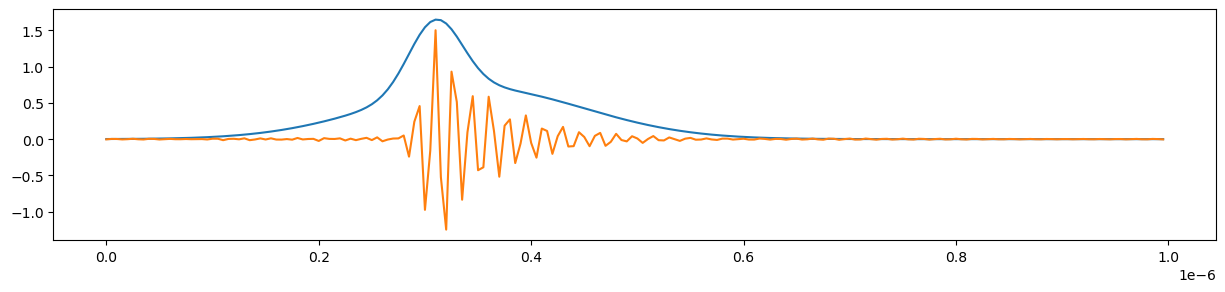

In [31]:
y = double_gaussian_window(x_vec, x_vec[np.argmax(true)], 0.025e-6, 0.7, 0.35e-6, 0.1e-6)
plt.figure(figsize=(15,3))
plt.plot(x_vec, y)
plt.plot(x_vec, true/np.max(true)*1.5)
plt.show()

In [33]:
class SignalModel_Double(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, window_amp1_prior, window_mean1_prior, window_std1_prior, x_grid):
        self.cf_model = cf_model
        self.x0 = window_mean_pos_prior
        self.sigma0 = window_std_prior
        self.A1 = window_amp1_prior
        self.x1 = window_mean1_prior
        self.sigma1 = window_std1_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def double_gaussian_window(self, x_grid, x0, sigma0, A1, x1, sigma1):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma0**2))+A1*np.exp(-(x_grid-x1)**2/(2*sigma1**2))

    def __call__(self, x):
        return self.cf_model(x) * self.double_gaussian_window(self.x_grid, self.x0(x), self.sigma0(x), self.A1(x), self.x1(x), self.sigma1(x))



In [ ]:
cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (1e-3, 1e-4),
    "loglogavgslope": (5., 1.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
}

window_mean_pos_prior = jft.NormalPrior(mean=3.1e-7, std=1e-8, name='mean_pos_window', shape=(1,))
window_std_prior = jft.NormalPrior(mean=3.1e-7, std=1e-8, name='std_window', shape=(1,))
window_mean_pos_prior = jft.NormalPrior(mean=3.1e-7, std=1e-8, name='mean_pos_window', shape=(1,))
window_std_prior = jft.NormalPrior(mean=3.1e-7, std=1e-8, name='std_window', shape=(1,))
window_mean_pos_prior = jft.NormalPrior(mean=3.1e-7, std=1e-8, name='mean_pos_window', shape=(1,))

shape = 200
distances = 5e-9

key, *subkeys = random.split(key, 3)

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

x_vec = cf_model.target_grids[0].distances[0] * np.arange(
    shape
)  # sampling points of Gaussian process
k_vec = cf_model.target_grids[
    0
].harmonic_grid.mode_lengths  # fourier modes of amplitude spectrum

model = SignalModel_Double(cf_model, window_mean_pos_prior, window_std_prior, x_vec)

xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for i, xi in enumerate(xi_samples):
    axes[0].plot(x_vec, model(xi))
    axes[0].plot(x_vec, true)
    axes[1].loglog(k_vec, ps(xi))
plt.show()

AttributeError: 'SignalModel' object has no attribute 'gaussian_window'

# Try Cutting Periodic

# Scipy Least Square (Failed)

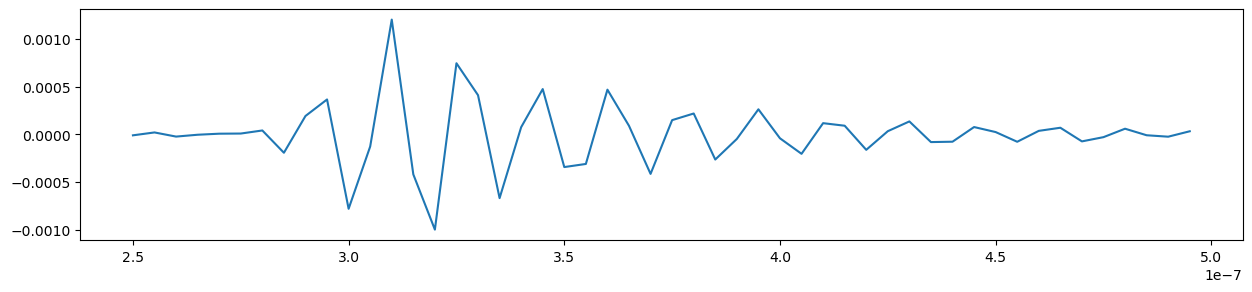

In [66]:
plt.figure(figsize=(15, 3))
plt.plot(t[50:100], true[50:100])
plt.show()

In [78]:
shape = 50
distances = 5e-9

In [103]:
seed = 50
key = random.PRNGKey(seed)
key, *subkeys = random.split(key, 2)

def func(m, s, s_s, f, f_s, l, l_s, x, x_s, a, a_s):
    cf_kwargs = {
    "offset_mean": m,
    "offset_std": (s, s_s),
    "fluctuations": (f, f_s),
    "loglogavgslope": (l, l_s),
    "flexibility": (x, x_s),
    "asperity": (a, a_s),
    "prefix": "",
}
    
    model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)
    xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

    return model(xi_samples[0])

In [80]:
from scipy.optimize import least_squares

In [ ]:
def residual(params):
    F = func(*params)
    return (F-true[50:100])*1e5

In [104]:
lower=[0, 0, 0, 0, 0, -10, 0, 0, 0, 0, 0]
upper=[1e-3, 1e-3, 1e-3, 1, 1, 10, 5, np.inf, np.inf, np.inf, np.inf]
p0 = (0, 1.71e-4, 1e-7, 2.9e-2, 1e-8, -2., 1., 10.0, 1.0, 1.0, 0.5,)

res = least_squares(residual, p0, bounds=(lower, upper), max_nfev=10000)

In [105]:
popt = res.x
popt

array([ 6.55694255e-05,  2.16674588e-04,  2.68910815e-05,  5.33625998e-03,
        4.36797266e-01, -9.89155276e+00,  1.74058807e-04,  6.87824216e+01,
        3.42623797e+01,  7.14866745e-07,  1.02000569e+01])

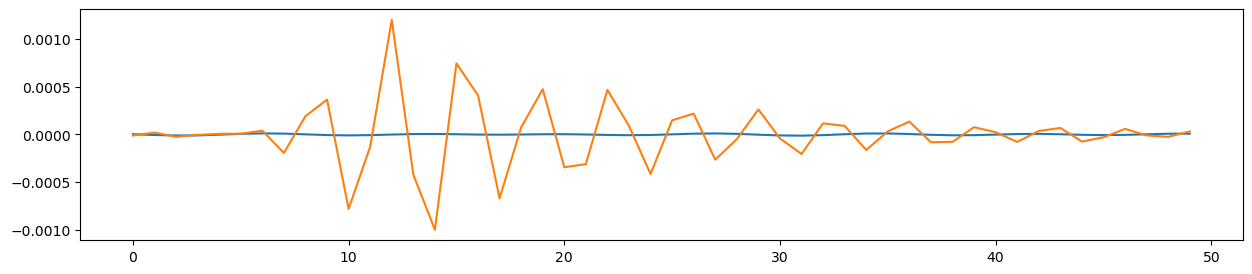

In [106]:
plt.figure(figsize=(15, 3))
plt.plot(func(*popt))
plt.plot(true[50:100])
plt.show()